In [1]:
%pip install pandas numpy scikit-learn transformers torch sentence-transformers matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import re
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

from transformers import pipeline, AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42
from tqdm.auto import tqdm

/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Change this path if necessary
df = pd.read_csv("/Users/yume/PycharmProjects/PBL2/data/reddit_dr.csv")

print(df.shape)
print(df.columns)

(12854, 9)
Index(['Title', 'Political Lean', 'Score', 'Id', 'Subreddit', 'URL',
       'Num of Comments', 'Text', 'Date Created'],
      dtype='object')


In [3]:
df["Title"] = df["Title"].fillna("").astype(str).str.strip()
df["Text"] = df["Text"].fillna("").astype(str).str.strip()

df["Text"] = (
    df["Title"]
    + " "
    + df["Text"]
).str.strip()

df["Political Lean"] = (
    df["Political Lean"]
    .astype(str)
    .str.strip()
)

df = df[
    df["Political Lean"].isin(
        ["Conservative", "Liberal"]
    )
].copy()

df = df[
    df["Text"].str.len() > 0
].reset_index(drop=True)

## RoBERTa sentiment features

In [4]:
sentiment_model = pipeline(
    task="text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    top_k=None,
    device=-1
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 36739.23it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
texts = df["Text"].tolist()

sentiment_results = sentiment_model(
    texts,
    batch_size=16,
    truncation=True,
    max_length=512
)

In [6]:
sentiment_rows = []

for result in sentiment_results:
    score_dictionary = {
        item["label"].lower(): item["score"]
        for item in result
    }

    # Handle models that return LABEL_0, LABEL_1, LABEL_2
    if "label_0" in score_dictionary:
        negative_score = score_dictionary.get("label_0", 0.0)
        neutral_score = score_dictionary.get("label_1", 0.0)
        positive_score = score_dictionary.get("label_2", 0.0)
    else:
        negative_score = score_dictionary.get("negative", 0.0)
        neutral_score = score_dictionary.get("neutral", 0.0)
        positive_score = score_dictionary.get("positive", 0.0)

    sentiment_rows.append({
        "roberta_negative": negative_score,
        "roberta_neutral": neutral_score,
        "roberta_positive": positive_score
    })

sentiment_df = pd.DataFrame(sentiment_rows)

sentiment_df.head()

,roberta_negative,roberta_neutral,roberta_positive
0,0.071206,0.681420,0.247375
1,0.004685,0.463182,0.532133
2,0.022105,0.912309,0.065586
3,0.714801,0.263404,0.021795
4,0.128113,0.596820,0.275068


In [7]:
df[
    [
        "roberta_negative",
        "roberta_neutral",
        "roberta_positive"
    ]
] = sentiment_df[
    [
        "roberta_negative",
        "roberta_neutral",
        "roberta_positive"
    ]
]

## RoBERTa final hidden-layer embeddings

In [8]:
# This extracts one 768-dimensional contextual embedding per Reddit post.
# It uses the final hidden layer from roberta-base and mean-pools non-padding tokens.

embedding_model_name = "roberta-base"

embedding_tokenizer = AutoTokenizer.from_pretrained(embedding_model_name)
embedding_model = AutoModel.from_pretrained(embedding_model_name)

if torch.cuda.is_available():
    embedding_device = torch.device("cuda")
elif torch.backends.mps.is_available():
    embedding_device = torch.device("mps")
else:
    embedding_device = torch.device("cpu")

embedding_model.to(embedding_device)
embedding_model.eval()

print("RoBERTa embedding device:", embedding_device)


def get_roberta_embeddings(
    texts,
    batch_size=16,
    max_length=256,
    normalize=True
):
    """
    Return a matrix of mean-pooled final-hidden-layer RoBERTa embeddings.

    Each row corresponds to one document. Padding tokens are excluded from
    the mean. L2 normalization is optional and enabled by default.
    """
    all_embeddings = []

    for start in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[start:start + batch_size]

        encoded = embedding_tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(embedding_device)
            for key, value in encoded.items()
        }

        with torch.inference_mode():
            outputs = embedding_model(**encoded)

        last_hidden_state = outputs.last_hidden_state
        attention_mask = encoded["attention_mask"].unsqueeze(-1)

        masked_hidden_state = last_hidden_state * attention_mask
        summed_hidden_state = masked_hidden_state.sum(dim=1)
        token_counts = attention_mask.sum(dim=1).clamp(min=1)

        batch_embeddings = summed_hidden_state / token_counts

        if normalize:
            batch_embeddings = torch.nn.functional.normalize(
                batch_embeddings,
                p=2,
                dim=1
            )

        all_embeddings.append(
            batch_embeddings.cpu().numpy()
        )

    return np.vstack(all_embeddings)


roberta_embeddings = get_roberta_embeddings(
    df["Text"].tolist(),
    batch_size=16,
    max_length=256,
    normalize=True
)

print("RoBERTa embedding matrix shape:", roberta_embeddings.shape)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8694.18it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa embedding device: mps


100%|██████████| 804/804 [03:33<00:00,  3.76it/s]

RoBERTa embedding matrix shape: (12854, 768)


In [9]:
roberta_embedding_df = pd.DataFrame(
    roberta_embeddings,
    columns=[
        f"roberta_embed_{i}"
        for i in range(roberta_embeddings.shape[1])
    ],
    index=df.index
)

df = pd.concat(
    [df, roberta_embedding_df],
    axis=1
)

roberta_embedding_features = roberta_embedding_df.columns.tolist()

print("Added embedding columns:", len(roberta_embedding_features))
print("Any missing embedding values:",
      df[roberta_embedding_features].isna().any().any())

df[roberta_embedding_features].head()


Added embedding columns: 768
Any missing embedding values: False


,roberta_embed_0,roberta_embed_1,roberta_embed_2,roberta_embed_3,roberta_embed_4,roberta_embed_5,roberta_embed_6,roberta_embed_7,roberta_embed_8,roberta_embed_9,...,roberta_embed_758,roberta_embed_759,roberta_embed_760,roberta_embed_761,roberta_embed_762,roberta_embed_763,roberta_embed_764,roberta_embed_765,roberta_embed_766,roberta_embed_767
0,-0.003242,0.006471,0.008163,-0.018306,0.000701,-0.007300,0.002353,0.007196,0.005535,0.006050,...,-0.006963,0.001248,-0.000153,-0.000525,0.002770,0.016060,0.006154,0.008525,-0.001826,0.005844
1,0.001243,0.016864,-0.000646,-0.000353,-0.011800,0.003662,0.003680,-0.003607,-0.002468,-0.005838,...,0.009292,0.001557,-0.004341,0.000472,-0.013887,0.001274,0.025650,0.015789,0.014663,0.002135
2,0.003174,0.001009,0.001541,-0.004856,-0.000624,0.005158,0.004913,0.004936,0.004388,-0.000182,...,-0.011704,-0.005695,-0.018339,0.007639,0.006934,0.007147,0.038500,0.005797,0.004929,0.008291
3,0.000058,0.007821,0.001372,-0.019020,0.014534,0.020016,0.003161,-0.009625,0.023772,-0.001063,...,0.000584,0.001499,0.004944,-0.009547,0.016795,0.006821,0.012308,0.021465,-0.002174,0.008404
4,0.001112,0.006951,0.003057,-0.000319,0.009763,-0.005203,-0.000072,-0.005595,0.009163,-0.005824,...,-0.002086,-0.001511,-0.009190,-0.002525,-0.003701,0.009884,0.022952,0.024720,0.001317,0.006085


## Moral-foundation virtue and violation features

Each moral foundation is split into a virtue and a corresponding violation:

- care / harm
- fairness / cheating
- loyalty / betrayal
- authority / subversion
- purity / degradation
- liberty / oppression

Each score is the cosine similarity between a post embedding and the mean embedding of multiple prototype descriptions.


In [10]:
moral_prototypes = {
    "care": [
        "The text emphasizes compassion, empathy, protection, and helping vulnerable people.",
        "The text supports reducing suffering and caring for people in need."
    ],
    "harm": [
        "The text describes cruelty, injury, neglect, violence, or causing suffering.",
        "The text condemns actions that hurt or endanger others."
    ],
    "fairness": [
        "The text emphasizes justice, equality, impartiality, and equal treatment.",
        "The text supports fair rules, equal rights, and equitable outcomes."
    ],
    "cheating": [
        "The text describes corruption, exploitation, dishonesty, or unfair advantage.",
        "The text accuses people or institutions of cheating or violating fair rules."
    ],
    "loyalty": [
        "The text emphasizes patriotism, group solidarity, loyalty, and commitment to a community.",
        "The text praises devotion to one's nation, party, or social group."
    ],
    "betrayal": [
        "The text describes betrayal, disloyalty, treason, or abandoning one's group.",
        "The text criticizes someone for failing their community, country, or allies."
    ],
    "authority": [
        "The text supports authority, hierarchy, obedience, law, and social order.",
        "The text expresses respect for leaders, institutions, rules, or tradition."
    ],
    "subversion": [
        "The text challenges authority, hierarchy, leaders, or established institutions.",
        "The text portrays authority or institutions as illegitimate, corrupt, or oppressive."
    ],
    "purity": [
        "The text emphasizes sanctity, purity, decency, cleanliness, or moral virtue.",
        "The text praises behavior seen as wholesome, sacred, or morally proper."
    ],
    "degradation": [
        "The text describes contamination, corruption, disgust, indecency, or moral degradation.",
        "The text portrays behavior or society as filthy, corrupt, or morally fallen."
    ],
    "liberty": [
        "The text emphasizes freedom, autonomy, civil rights, personal choice, and independence.",
        "The text supports resistance to coercion and protection of individual freedom."
    ],
    "oppression": [
        "The text describes domination, coercion, censorship, control, or loss of freedom.",
        "The text portrays people as being oppressed, restricted, or forced by powerful institutions."
    ]
}


In [11]:
semantic_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

# Encode the same combined Title + Text used by every other feature block.
post_embeddings = semantic_model.encode(
    df["Text"].fillna("").astype(str).tolist(),
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Post embedding shape:", post_embeddings.shape)


Batches: 100%|██████████| 402/402 [00:16<00:00, 24.56it/s]

Post embedding shape: (12854, 384)


In [12]:
prototype_names = list(moral_prototypes.keys())
prototype_embeddings = []

for name in prototype_names:
    embeddings = semantic_model.encode(
        moral_prototypes[name],
        normalize_embeddings=True
    )

    mean_embedding = embeddings.mean(axis=0)
    mean_embedding = mean_embedding / np.linalg.norm(mean_embedding)

    prototype_embeddings.append(mean_embedding)

prototype_embeddings = np.vstack(prototype_embeddings)

print("Prototype embedding shape:", prototype_embeddings.shape)


Prototype embedding shape: (12, 384)


In [13]:
moral_scores = post_embeddings @ prototype_embeddings.T

moral_df = pd.DataFrame(
    moral_scores,
    columns=[f"moral_{name}" for name in prototype_names],
    index=df.index
)

df[moral_df.columns] = moral_df

df[moral_df.columns].head()


/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_48097/775870590.py:1: RuntimeWarning: divide by zero encountered in matmul
  moral_scores = post_embeddings @ prototype_embeddings.T
/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_48097/775870590.py:1: RuntimeWarning: overflow encountered in matmul
  moral_scores = post_embeddings @ prototype_embeddings.T
/var/folders/1z/hv4_qzyn6556dk5hqb4k6tdh0000gn/T/ipykernel_48097/775870590.py:1: RuntimeWarning: invalid value encountered in matmul
  moral_scores = post_embeddings @ prototype_embeddings.T


,moral_care,moral_harm,moral_fairness,moral_cheating,moral_loyalty,moral_betrayal,moral_authority,moral_subversion,moral_purity,moral_degradation,moral_liberty,moral_oppression
0,0.232020,0.174915,0.320648,0.231477,0.337275,0.297266,0.343032,0.316333,0.251408,0.288956,0.285621,0.333226
1,0.022097,-0.011459,0.028100,0.044209,0.081291,0.029701,-0.042054,-0.011173,-0.007703,0.035487,-0.006393,0.056773
2,-0.011938,0.010951,0.081846,0.057631,0.124413,0.091079,-0.000581,0.075318,0.035335,0.050541,0.107004,0.089619
3,0.253545,0.113793,0.151775,0.168012,0.172952,0.089151,0.035429,0.093743,0.080520,0.187843,0.087560,0.071509
4,0.084154,0.064445,0.046192,-0.001029,0.006298,0.008347,0.036804,-0.028752,0.091167,0.119887,0.043016,-0.050080


In [14]:
contrast_features = {
    "care_minus_harm": ("moral_care", "moral_harm"),
    "fairness_minus_cheating": ("moral_fairness", "moral_cheating"),
    "loyalty_minus_betrayal": ("moral_loyalty", "moral_betrayal"),
    "authority_minus_subversion": ("moral_authority", "moral_subversion"),
    "purity_minus_degradation": ("moral_purity", "moral_degradation"),
    "liberty_minus_oppression": ("moral_liberty", "moral_oppression")
}

for new_feature, (virtue_feature, violation_feature) in contrast_features.items():
    df[new_feature] = df[virtue_feature] - df[violation_feature]

df[list(contrast_features.keys())].head()


,care_minus_harm,fairness_minus_cheating,loyalty_minus_betrayal,authority_minus_subversion,purity_minus_degradation,liberty_minus_oppression
0,0.057105,0.089170,0.040009,0.026699,-0.037548,-0.047605
1,0.033556,-0.016109,0.051590,-0.030881,-0.043190,-0.063165
2,-0.022889,0.024215,0.033334,-0.075899,-0.015205,0.017385
3,0.139752,-0.016236,0.083801,-0.058314,-0.107322,0.016050
4,0.019710,0.047221,-0.002049,0.065556,-0.028721,0.093096


In [15]:
moral_feature_names = [
    f"moral_{name}"
    for name in prototype_names
]

moral_contrast_features = list(contrast_features.keys())

print("Moral virtue/violation features:", moral_feature_names)
print("Moral contrast features:", moral_contrast_features)


Moral virtue/violation features: ['moral_care', 'moral_harm', 'moral_fairness', 'moral_cheating', 'moral_loyalty', 'moral_betrayal', 'moral_authority', 'moral_subversion', 'moral_purity', 'moral_degradation', 'moral_liberty', 'moral_oppression']
Moral contrast features: ['care_minus_harm', 'fairness_minus_cheating', 'loyalty_minus_betrayal', 'authority_minus_subversion', 'purity_minus_degradation', 'liberty_minus_oppression']


In [16]:
df[
    moral_feature_names + moral_contrast_features
].describe().T


,count,mean,std,min,25%,50%,75%,max
moral_care,12854.0,0.084739,0.081813,-0.166414,0.026191,0.078882,0.138803,0.435061
moral_harm,12854.0,0.106262,0.089002,-0.149531,0.042657,0.102790,0.165892,0.522006
moral_fairness,12854.0,0.110681,0.083746,-0.160635,0.052790,0.106003,0.164165,0.562694
moral_cheating,12854.0,0.136504,0.087119,-0.138013,0.074752,0.134563,0.196112,0.523591
moral_loyalty,12854.0,0.102995,0.098154,-0.188102,0.032696,0.096470,0.169077,0.495630
moral_betrayal,12854.0,0.137702,0.094297,-0.156569,0.070582,0.135485,0.204107,0.567483
moral_authority,12854.0,0.078105,0.090459,-0.192106,0.013774,0.070779,0.135806,0.483962
moral_subversion,12854.0,0.123934,0.092817,-0.134316,0.057197,0.118786,0.185182,0.562317
moral_purity,12854.0,0.069818,0.085741,-0.195076,0.008125,0.064057,0.123776,0.428155
moral_degradation,12854.0,0.130872,0.091719,-0.140045,0.065862,0.129221,0.194193,0.498265


In [17]:
df.to_csv(
    "reddit_with_semantic_features.csv",
    index=False
)

print("Saved enriched dataframe.")

Saved enriched dataframe.


## Model feature groups

The models below use the same train/test split:

- **TF-IDF only**
- **RoBERTa sentiment + virtue/violation moral scores + moral contrasts + all 768 RoBERTa embedding dimensions**
- **TF-IDF + all semantic features**

The RoBERTa embedding dimensions are latent and should be analyzed as a feature block rather than interpreted individually.


In [18]:
sentiment_features = [
    "roberta_negative",
    "roberta_neutral",
    "roberta_positive"
]

# Twelve virtue/violation similarity features
moral_features = moral_feature_names.copy()

# Six directional contrast features
moral_contrast_features = [
    "care_minus_harm",
    "fairness_minus_cheating",
    "loyalty_minus_betrayal",
    "authority_minus_subversion",
    "purity_minus_degradation",
    "liberty_minus_oppression"
]

# 768-dimensional final-hidden-layer RoBERTa embeddings
roberta_embedding_features = [
    column
    for column in df.columns
    if column.startswith("roberta_embed_")
]

semantic_features = (
    sentiment_features
    + moral_features
    + moral_contrast_features
    + roberta_embedding_features
)

all_feature_columns = ["Text"] + semantic_features

print("Number of sentiment features:", len(sentiment_features))
print("Number of moral virtue/violation features:", len(moral_features))
print("Number of moral contrast features:", len(moral_contrast_features))
print("Number of RoBERTa embedding features:", len(roberta_embedding_features))
print("Total numeric semantic features:", len(semantic_features))

assert len(moral_features) == 12, "Expected 12 virtue/violation features."
assert len(moral_contrast_features) == 6, "Expected 6 contrast features."
assert len(roberta_embedding_features) == 768, "Expected 768 RoBERTa embedding dimensions."


Number of sentiment features: 3
Number of moral virtue/violation features: 12
Number of moral contrast features: 6
Number of RoBERTa embedding features: 768
Total numeric semantic features: 789


In [19]:
model_df = df.dropna(
    subset=[
        "Text",
        "Political Lean"
    ] + semantic_features
).copy()

In [20]:
X = model_df[all_feature_columns]
y = model_df["Political Lean"]

print(X.shape)
print(y.value_counts())

(12854, 790)
Political Lean
Liberal         8319
Conservative    4535
Name: count, dtype: int64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

Training rows: 10283
Test rows: 2571


In [22]:
full_preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.95,
                sublinear_tf=True,
                max_features=50000
            ),
            "Text"
        ),

        (
            "semantic",
            StandardScaler(),
            semantic_features
        )
    ],
    remainder="drop"
)

In [23]:
full_pipeline = Pipeline([
    (
        "preprocessor",
        full_preprocessor
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [24]:
full_param_grid = {
    "preprocessor__tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "preprocessor__tfidf__min_df": [
        2,
        3,
        5
    ],

    "preprocessor__tfidf__stop_words": [
        None,
        "english"
    ],

    "classifier__C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]
}

In [25]:
full_search = GridSearchCV(
    estimator=full_pipeline,
    param_grid=full_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

full_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,estimator,Pipeline(step...liblinear'))])
,param_grid,"{'classifier__C': [0.1, 0.5, ...], 'preprocessor__tfidf__min_df': [2, 3, ...], 'preprocessor__tfidf__ngram_range': [(1, ...), (1, ...)], 'preprocessor__tfidf__stop_words': [None, 'english']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,transformers,"[('tfidf', ...), ('semantic', ...)]"


In [26]:
best_full_model = full_search.best_estimator_

full_predictions = best_full_model.predict(
    X_test
)

full_accuracy = accuracy_score(
    y_test,
    full_predictions
)

full_macro_f1 = f1_score(
    y_test,
    full_predictions,
    average="macro"
)

print("Best parameters:")
print(full_search.best_params_)

print("\nBest CV macro F1:")
print(full_search.best_score_)

print("\nTest accuracy:")
print(full_accuracy)

print("\nTest macro F1:")
print(full_macro_f1)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        full_predictions
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        full_predictions
    )
)

Best parameters:
{'classifier__C': 5, 'preprocessor__tfidf__min_df': 2, 'preprocessor__tfidf__ngram_range': (1, 2), 'preprocessor__tfidf__stop_words': 'english'}

Best CV macro F1:
0.7416207193002811

Test accuracy:
0.7685725398677558

Test macro F1:
0.7517107626655517

Classification report:
              precision    recall  f1-score   support

Conservative       0.66      0.72      0.69       907
     Liberal       0.84      0.80      0.82      1664

    accuracy                           0.77      2571
   macro avg       0.75      0.76      0.75      2571
weighted avg       0.77      0.77      0.77      2571


Confusion matrix:
[[ 653  254]
 [ 341 1323]]


## TF-IDF only

In [27]:
tfidf_only_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True,
            max_df=0.95,
            max_features=50000
        )
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            penalty="l2",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [28]:
tfidf_only_param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2)
    ],

    "tfidf__min_df": [
        2,
        3,
        5
    ],

    "tfidf__stop_words": [
        None,
        "english"
    ],

    "classifier__C": [
        0.1,
        0.5,
        1,
        2,
        5
    ]
}

In [29]:
tfidf_only_search = GridSearchCV(
    estimator=tfidf_only_pipeline,
    param_grid=tfidf_only_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=2
)

tfidf_only_search.fit(
    X_train["Text"],
    y_train
)

tfidf_only_predictions = tfidf_only_search.predict(
    X_test["Text"]
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


## roberta, moral w/o tfidf

In [30]:
semantic_only_pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            solver="liblinear",
            class_weight="balanced",
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    )
])

In [31]:
semantic_only_search = GridSearchCV(
    estimator=semantic_only_pipeline,
    param_grid={
        "classifier__C": [
            0.01,
            0.1,
            0.5,
            1,
            2,
            5,
            10
        ]
    },
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

semantic_only_search.fit(
    X_train[semantic_features],
    y_train
)

semantic_only_predictions = (
    semantic_only_search.predict(
        X_test[semantic_features]
    )
)

/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yume/PycharmProjects/PBL2/.venv1/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yume/Pychar

In [35]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF only",
        "Sentiment + moral + RoBERTa embeddings only",
        "TF-IDF + sentiment + moral + RoBERTa embeddings"
    ],

    "Accuracy": [
        accuracy_score(
            y_test,
            tfidf_only_predictions
        ),

        accuracy_score(
            y_test,
            semantic_only_predictions
        ),

        accuracy_score(
            y_test,
            full_predictions
        )
    ],

    "Macro F1": [
        f1_score(
            y_test,
            tfidf_only_predictions,
            average="macro"
        ),

        f1_score(
            y_test,
            semantic_only_predictions,
            average="macro"
        ),

        f1_score(
            y_test,
            full_predictions,
            average="macro"
        )
    ],

    "Best CV Macro F1": [
        tfidf_only_search.best_score_,
        semantic_only_search.best_score_,
        full_search.best_score_
    ]
})

comparison

,Model,Accuracy,Macro F1,Best CV Macro F1
0,TF-IDF only,0.781797,0.760662,0.749247
1,Sentiment + moral + RoBERTa embeddings only,0.708674,0.695846,0.692785
2,TF-IDF + sentiment + moral + RoBERTa embeddings,0.768573,0.751711,0.741621


## Semantic feature-block analysis

Individual RoBERTa dimensions are latent and should not be interpreted one by one.  
This section summarizes the overall coefficient magnitude assigned to sentiment, moral-foundation, and embedding feature blocks.


In [36]:
# Analyze coefficient magnitude by semantic feature block
semantic_classifier = semantic_only_search.best_estimator_.named_steps["classifier"]
semantic_coefficients = semantic_classifier.coef_[0]

n_sentiment = len(sentiment_features)
n_moral = len(moral_features)
n_contrasts = len(moral_contrast_features)
n_embeddings = len(roberta_embedding_features)

block_slices = {
    "RoBERTa sentiment": slice(0, n_sentiment),
    "Moral virtue/violation": slice(n_sentiment, n_sentiment + n_moral),
    "Moral contrasts": slice(
        n_sentiment + n_moral,
        n_sentiment + n_moral + n_contrasts
    ),
    "RoBERTa embeddings": slice(
        n_sentiment + n_moral + n_contrasts,
        n_sentiment + n_moral + n_contrasts + n_embeddings
    )
}

block_summary = []

for block_name, block_slice in block_slices.items():
    block_coef = semantic_coefficients[block_slice]
    block_summary.append({
        "feature_block": block_name,
        "number_of_features": len(block_coef),
        "mean_absolute_coefficient": np.mean(np.abs(block_coef)),
        "sum_absolute_coefficient": np.sum(np.abs(block_coef)),
        "max_absolute_coefficient": np.max(np.abs(block_coef))
    })

block_summary_df = pd.DataFrame(block_summary)
block_summary_df


,feature_block,number_of_features,mean_absolute_coefficient,sum_absolute_coefficient,max_absolute_coefficient
0,RoBERTa sentiment,3,0.026142,0.078427,0.041813
1,Moral virtue/violation,12,0.054586,0.655038,0.140637
2,Moral contrasts,6,0.031309,0.187857,0.070326
3,RoBERTa embeddings,768,0.046367,35.610220,0.175663


In [37]:
full_classifier = (
    best_full_model
    .named_steps["classifier"]
)

print(full_classifier.classes_)

['Conservative' 'Liberal']


In [38]:
full_preprocessor_fitted = (
    best_full_model
    .named_steps["preprocessor"]
)

feature_names = (
    full_preprocessor_fitted
    .get_feature_names_out()
)

coefficients = full_classifier.coef_[0]

coefficient_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "absolute_coefficient": np.abs(coefficients)
})

In [39]:
semantic_coefficient_df = (
    coefficient_df[
        coefficient_df["feature"]
        .str.startswith("semantic__")
    ]
    .copy()
)

semantic_coefficient_df["feature"] = (
    semantic_coefficient_df["feature"]
    .str.replace(
        "semantic__",
        "",
        regex=False
    )
)

semantic_coefficient_df = (
    semantic_coefficient_df
    .sort_values(
        "coefficient",
        ascending=False
    )
)

semantic_coefficient_df

,feature,coefficient,absolute_coefficient
32832,roberta_embed_77,0.753153,0.753153
33085,roberta_embed_330,0.454362,0.454362
33086,roberta_embed_331,0.425381,0.425381
32771,roberta_embed_16,0.425342,0.425342
33504,roberta_embed_749,0.364277,0.364277
...,...,...,...
33459,roberta_embed_704,-0.228288,0.228288
33419,roberta_embed_664,-0.233136,0.233136
32995,roberta_embed_240,-0.239693,0.239693
33354,roberta_embed_599,-0.290072,0.290072


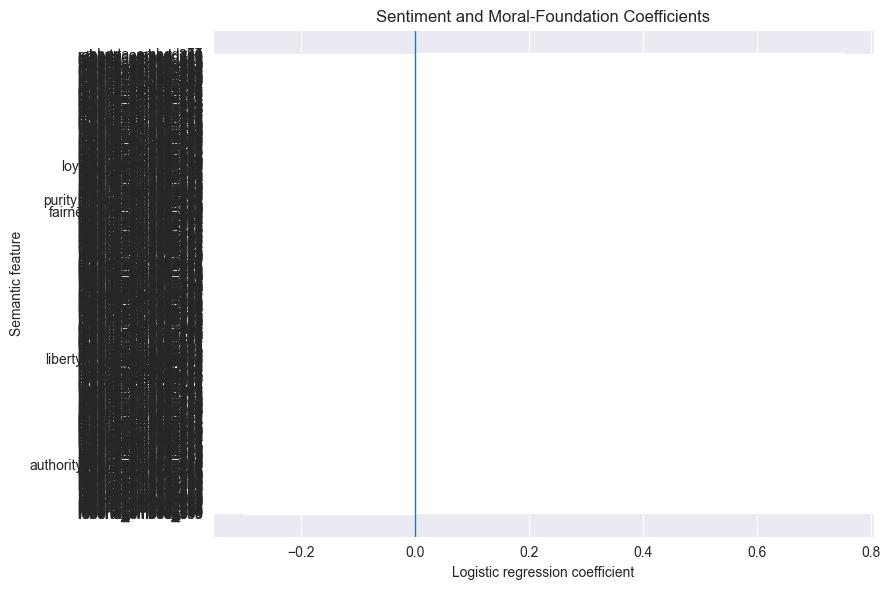

In [40]:
plot_df = semantic_coefficient_df.sort_values(
    "coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["feature"],
    plot_df["coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Logistic regression coefficient")
plt.ylabel("Semantic feature")
plt.title(
    "Sentiment and Moral-Foundation Coefficients"
)

plt.tight_layout()
plt.show()

In [41]:
semantic_group_summary = (
    model_df
    .groupby("Political Lean")[
        semantic_features
    ]
    .mean()
    .T
)

semantic_group_summary


Political Lean,Conservative,Liberal
roberta_negative,0.357323,0.354796
roberta_neutral,0.531397,0.529643
roberta_positive,0.111281,0.115561
moral_care,0.072050,0.091657
moral_harm,0.100134,0.109603
...,...,...
roberta_embed_763,0.006063,0.006157
roberta_embed_764,0.014152,0.014453
roberta_embed_765,0.005236,0.005328
roberta_embed_766,-0.000020,-0.000018


In [42]:
semantic_group_summary["Liberal_minus_Conservative"] = (
    semantic_group_summary["Liberal"]
    - semantic_group_summary["Conservative"]
)

semantic_group_summary.sort_values(
    "Liberal_minus_Conservative",
    ascending=False
)

Political Lean,Conservative,Liberal,Liberal_minus_Conservative
fairness_minus_cheating,-0.039189,-0.018536,0.020652
moral_care,0.072050,0.091657,0.019606
moral_fairness,0.099440,0.116809,0.017370
moral_loyalty,0.092223,0.108867,0.016644
moral_liberty,0.121777,0.135156,0.013378
...,...,...,...
roberta_embed_652,0.012563,0.009693,-0.002870
roberta_embed_397,0.006641,0.003719,-0.002922
roberta_embed_247,0.007979,0.004856,-0.003123
moral_cheating,0.138629,0.135346,-0.003283


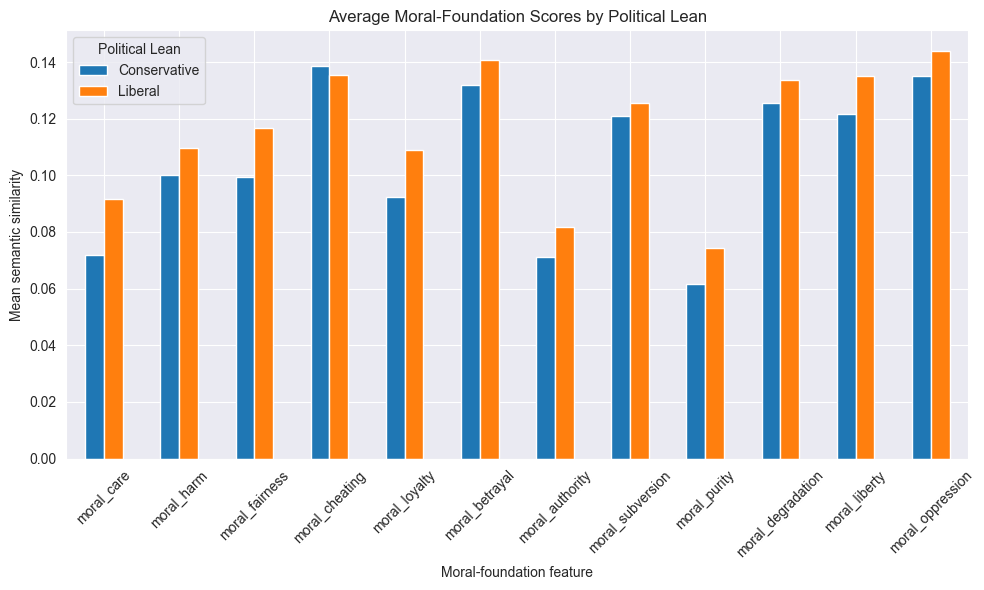

In [43]:
moral_group_means = (
    model_df
    .groupby("Political Lean")[
        moral_features
    ]
    .mean()
    .T
)

moral_group_means.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Mean semantic similarity")
plt.xlabel("Moral-foundation feature")
plt.title(
    "Average Moral-Foundation Scores by Political Lean"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [44]:
df

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created,roberta_negative,...,moral_purity,moral_degradation,moral_liberty,moral_oppression,care_minus_harm,fairness_minus_cheating,loyalty_minus_betrayal,authority_minus_subversion,purity_minus_degradation,liberty_minus_oppression
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,"No matter who someone is, how they look like, ...",1.646272e+09,0.071206,...,0.251408,0.288956,0.285621,0.333226,0.057105,0.089170,0.040009,0.026699,-0.037548,-0.047605
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,Biden speech draws 38.2 million U.S. TV viewers,1.646271e+09,0.004685,...,-0.007703,0.035487,-0.006393,0.056773,0.033556,-0.016109,0.051590,-0.030881,-0.043190,-0.063165
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,State of the union Who watched the state of th...,1.646270e+09,0.022105,...,0.035335,0.050541,0.107004,0.089619,-0.022889,0.024215,0.033334,-0.075899,-0.015205,0.017385
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,We Should Just Give Poor People Money,1.646270e+09,0.714801,...,0.080520,0.187843,0.087560,0.071509,0.139752,-0.016236,0.083801,-0.058314,-0.107322,0.016050
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,Do it for the Dew,1.646268e+09,0.128113,...,0.091167,0.119887,0.043016,-0.050080,0.019710,0.047221,-0.002049,0.065556,-0.028721,0.093096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12849,Ron Paul’s Spirited Defense of WikiLeaks & Fre...,Conservative,2,em7rm,anarchocapitalism,http://www.deathandtaxesmag.com/40485/ron-paul...,1,Ron Paul’s Spirited Defense of WikiLeaks & Fre...,1.292421e+09,0.156991,...,0.161733,0.254024,0.277110,0.285375,-0.091717,-0.121644,-0.103528,-0.068979,-0.092291,-0.008265
12850,"“Anarcho-capitalism, in my opinion, is a doctr...",Conservative,2,ei98o,anarchocapitalism,http://www.pressaction.com/news/weblog/full_ar...,1,"“Anarcho-capitalism, in my opinion, is a doctr...",1.291813e+09,0.891309,...,0.250684,0.374187,0.404837,0.506863,-0.006645,-0.032573,-0.017648,-0.093568,-0.123504,-0.102026
12851,Mises Wiki is a wiki project dedicated to the ...,Conservative,2,e6x22,anarchocapitalism,http://wiki.mises.org/wiki/Main_Page,0,Mises Wiki is a wiki project dedicated to the ...,1.289910e+09,0.004379,...,0.041824,0.155099,0.125438,0.158979,0.039524,-0.033614,-0.079266,-0.055766,-0.113274,-0.033541
12852,Fireman Protection Monopoly - Is This Failed C...,Conservative,2,e4vtd,anarchocapitalism,http://www.csmonitor.com/Business/Mises-Econom...,0,Fireman Protection Monopoly - Is This Failed C...,1.289524e+09,0.713035,...,0.012069,0.132434,0.203541,0.232664,-0.072717,-0.099054,-0.032010,-0.085074,-0.120365,-0.029122


In [45]:
df.describe()

,Score,Num of Comments,Date Created,roberta_negative,roberta_neutral,roberta_positive,roberta_embed_0,roberta_embed_1,roberta_embed_2,roberta_embed_3,...,moral_purity,moral_degradation,moral_liberty,moral_oppression,care_minus_harm,fairness_minus_cheating,loyalty_minus_betrayal,authority_minus_subversion,purity_minus_degradation,liberty_minus_oppression
count,12854.000000,12854.000000,1.285400e+04,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,...,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000
mean,118.558270,19.055936,1.622576e+09,0.355687,0.530262,0.114051,0.000612,0.005287,0.001743,-0.005864,...,0.069818,0.130872,0.130436,0.140810,-0.021523,-0.025823,-0.034707,-0.045829,-0.061054,-0.010375
std,498.888034,60.381567,6.112838e+07,0.305225,0.266974,0.196808,0.004052,0.004801,0.004029,0.007035,...,0.085741,0.091719,0.099290,0.105553,0.070857,0.075128,0.074840,0.047425,0.057165,0.047885
min,0.000000,0.000000,1.231048e+09,0.001571,0.006276,0.003942,-0.016808,-0.015962,-0.015575,-0.043880,...,-0.195076,-0.140045,-0.168758,-0.144554,-0.262561,-0.340696,-0.301375,-0.217585,-0.316833,-0.179320
25%,3.000000,1.000000,1.632132e+09,0.052306,0.291912,0.014973,-0.002019,0.002143,-0.000945,-0.010493,...,0.008125,0.065862,0.059544,0.063762,-0.069215,-0.073961,-0.085735,-0.077562,-0.099812,-0.042855
50%,12.000000,3.000000,1.642030e+09,0.290973,0.546549,0.033015,0.000559,0.005224,0.001906,-0.005913,...,0.064057,0.129221,0.124376,0.134127,-0.018354,-0.024435,-0.035132,-0.045872,-0.061082,-0.011625
75%,65.000000,15.000000,1.645107e+09,0.635424,0.776043,0.098283,0.003235,0.008425,0.004466,-0.001215,...,0.123776,0.194193,0.194504,0.213451,0.027562,0.022788,0.016665,-0.013997,-0.023101,0.022509
max,25055.000000,2150.000000,1.646272e+09,0.964650,0.967071,0.991370,0.016317,0.025821,0.016495,0.023431,...,0.428155,0.498265,0.614112,0.582247,0.245066,0.267972,0.232073,0.176569,0.201064,0.159098


array([[<Axes: title={'center': 'Score'}>,
        <Axes: title={'center': 'Num of Comments'}>,
        <Axes: title={'center': 'Date Created'}>,
        <Axes: title={'center': 'roberta_negative'}>,
        <Axes: title={'center': 'roberta_neutral'}>,
        <Axes: title={'center': 'roberta_positive'}>,
        <Axes: title={'center': 'roberta_embed_0'}>,
        <Axes: title={'center': 'roberta_embed_1'}>,
        <Axes: title={'center': 'roberta_embed_2'}>,
        <Axes: title={'center': 'roberta_embed_3'}>,
        <Axes: title={'center': 'roberta_embed_4'}>,
        <Axes: title={'center': 'roberta_embed_5'}>,
        <Axes: title={'center': 'roberta_embed_6'}>,
        <Axes: title={'center': 'roberta_embed_7'}>,
        <Axes: title={'center': 'roberta_embed_8'}>,
        <Axes: title={'center': 'roberta_embed_9'}>,
        <Axes: title={'center': 'roberta_embed_10'}>,
        <Axes: title={'center': 'roberta_embed_11'}>,
        <Axes: title={'center': 'roberta_embed_12'}>,
 

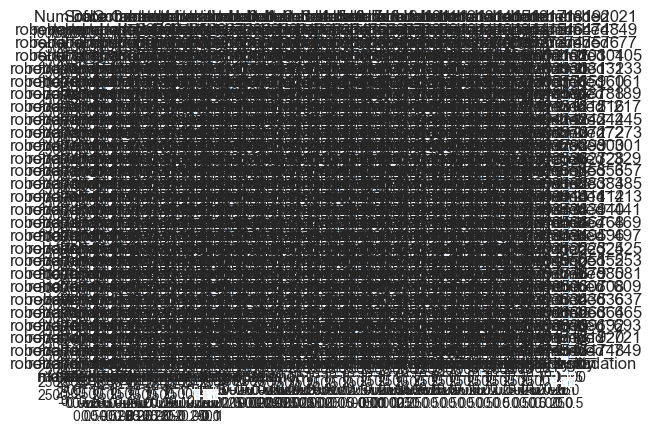

In [46]:
df.hist()

In [ ]:
df.plot()

## Running a ton of classifiers

In [32]:
import time
import warnings
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [33]:
print("Sentiment features:", len(sentiment_features))
print("Moral features:", len(moral_features))
print("Moral contrast features:", len(moral_contrast_features))
print("RoBERTa embedding features:", len(roberta_embedding_features))
print("All semantic features:", len(semantic_features))

Sentiment features: 3
Moral features: 12
Moral contrast features: 6
RoBERTa embedding features: 768
All semantic features: 789


### preprocessors

In [34]:
tfidf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_df=0.95,
                max_features=50000
            ),
            "Text"
        )
    ],
    remainder="drop"
)

In [35]:
semantic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "semantic",
            StandardScaler(),
            semantic_features
        )
    ],
    remainder="drop"
)

In [36]:
full_preprocessor = ColumnTransformer(
    transformers=[
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                sublinear_tf=True,
                max_df=0.95,
                max_features=50000
            ),
            "Text"
        ),
        (
            "semantic",
            StandardScaler(),
            semantic_features
        )
    ],
    remainder="drop"
)

## feature set configs

In [37]:
feature_sets = {
    "TF-IDF only": {
        "preprocessor": tfidf_preprocessor,
        "use_dimensionality_reduction": True
    },

    "Semantic only": {
        "preprocessor": semantic_preprocessor,
        "use_dimensionality_reduction": False
    },

    "TF-IDF + semantic": {
        "preprocessor": full_preprocessor,
        "use_dimensionality_reduction": True
    }
}

## define classifiers, parameter grids

In [38]:
classifier_configs = {
    "Logistic Regression": {
        "estimator": LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ),
        "param_grid": [
            {
                "classifier__solver": ["liblinear"],
                "classifier__penalty": ["l1", "l2"],
                "classifier__C": [0.01, 0.1, 0.5, 1, 2, 5, 10]
            }
        ],
        "requires_dense_reduction": False
    },

    "Linear SVM": {
        "estimator": LinearSVC(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "classifier__C": [
                0.001,
                0.01,
                0.1,
                0.5,
                1,
                2,
                5,
                10
            ]
        },
        "requires_dense_reduction": False
    },

    "SGD Linear SVM": {
        "estimator": SGDClassifier(
            loss="hinge",
            class_weight="balanced",
            max_iter=3000,
            early_stopping=True,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "classifier__alpha": [
                1e-5,
                1e-4,
                1e-3,
                1e-2
            ],
            "classifier__penalty": [
                "l2",
                "l1",
                "elasticnet"
            ]
        },
        "requires_dense_reduction": False
    },

    "RBF SVM": {
        "estimator": SVC(
            kernel="rbf",
            class_weight="balanced",
            cache_size=4000,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "classifier__C": [
                0.1,
                1,
                3,
                10,
                30
            ],
            "classifier__gamma": [
                "scale",
                0.001,
                0.01,
                0.1
            ]
        },
        "requires_dense_reduction": True
    },

    "Extra Trees": {
        "estimator": ExtraTreesClassifier(
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE
        ),
        "param_grid": {
            "classifier__n_estimators": [
                300,
                500
            ],
            "classifier__max_depth": [
                None,
                10,
                20
            ],
            "classifier__min_samples_leaf": [
                1,
                2,
                5
            ],
            "classifier__max_features": [
                "sqrt",
                0.5
            ]
        },
        "requires_dense_reduction": True
    },

    "Histogram Gradient Boosting": {
        "estimator": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            early_stopping=True
        ),
        "param_grid": {
            "classifier__learning_rate": [
                0.03,
                0.1,
                0.2
            ],
            "classifier__max_iter": [
                100,
                200
            ],
            "classifier__max_leaf_nodes": [
                15,
                31,
                63
            ],
            "classifier__l2_regularization": [
                0,
                0.1,
                1
            ]
        },
        "requires_dense_reduction": True
    }
}

## helpers

In [39]:
def build_experiment_pipeline(
    preprocessor,
    classifier,
    feature_set_name,
    requires_dense_reduction
):
    steps = [
        ("preprocessor", clone(preprocessor))
    ]

    if requires_dense_reduction and feature_set_name != "Semantic only":
        steps.append(
            (
                "svd",
                TruncatedSVD(
                    n_components=200,
                    random_state=RANDOM_STATE
                )
            )
        )

        steps.append(
            (
                "post_svd_scaler",
                StandardScaler()
            )
        )

    steps.append(
        (
            "classifier",
            clone(classifier)
        )
    )

    return Pipeline(steps)




def prepare_parameter_grid(
    base_grid,
    feature_set_name,
    requires_dense_reduction
):
    if isinstance(base_grid, list):
        grids = [grid.copy() for grid in base_grid]
    else:
        grids = [base_grid.copy()]

    if requires_dense_reduction and feature_set_name != "Semantic only":
        for grid in grids:
            grid["svd__n_components"] = [
                50,
                100,
                200
            ]

    return grids

In [40]:
'''
all_results = []
all_searches = {}
all_predictions = {}

for feature_set_name, feature_config in feature_sets.items():

    print("\n" + "=" * 80)
    print("FEATURE SET:", feature_set_name)
    print("=" * 80)

    for classifier_name, classifier_config in classifier_configs.items():

        print(f"\nRunning: {classifier_name}")
        print("-" * 60)

        pipeline = build_experiment_pipeline(
            preprocessor=feature_config["preprocessor"],
            classifier=classifier_config["estimator"],
            feature_set_name=feature_set_name,
            requires_dense_reduction=classifier_config[
                "requires_dense_reduction"
            ]
        )

        param_grid = prepare_parameter_grid(
            base_grid=classifier_config["param_grid"],
            feature_set_name=feature_set_name,
            requires_dense_reduction=classifier_config[
                "requires_dense_reduction"
            ]
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="f1_macro",
            cv=5,
            n_jobs=-1,
            verbose=1,
            return_train_score=True,
            error_score="raise"
        )

        start_time = time.time()

        try:
            search.fit(
                X_train,
                y_train
            )

            elapsed_seconds = time.time() - start_time

            predictions = search.predict(
                X_test
            )

            accuracy = accuracy_score(
                y_test,
                predictions
            )

            macro_f1 = f1_score(
                y_test,
                predictions,
                average="macro"
            )

            weighted_f1 = f1_score(
                y_test,
                predictions,
                average="weighted"
            )

            result_key = (
                feature_set_name,
                classifier_name
            )

            all_searches[result_key] = search
            all_predictions[result_key] = predictions

            all_results.append({
                "Feature Set": feature_set_name,
                "Classifier": classifier_name,
                "Accuracy": accuracy,
                "Test Macro F1": macro_f1,
                "Test Weighted F1": weighted_f1,
                "CV Macro F1": search.best_score_,
                "Runtime Seconds": elapsed_seconds,
                "Best Parameters": search.best_params_
            })

            print("Best parameters:", search.best_params_)
            print("Best CV macro F1:", round(search.best_score_, 4))
            print("Test accuracy:", round(accuracy, 4))
            print("Test macro F1:", round(macro_f1, 4))
            print("Runtime:", round(elapsed_seconds, 1), "seconds")

        except Exception as error:
            elapsed_seconds = time.time() - start_time

            print(
                f"Experiment failed after "
                f"{elapsed_seconds:.1f} seconds:"
            )
            print(error)

            all_results.append({
                "Feature Set": feature_set_name,
                "Classifier": classifier_name,
                "Accuracy": np.nan,
                "Test Macro F1": np.nan,
                "Test Weighted F1": np.nan,
                "CV Macro F1": np.nan,
                "Runtime Seconds": elapsed_seconds,
                "Best Parameters": f"FAILED: {error}"
            })
'''


FEATURE SET: TF-IDF only

Running: Logistic Regression
------------------------------------------------------------
Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best parameters: {'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best CV macro F1: 0.7419
Test accuracy: 0.7612
Test macro F1: 0.7394
Runtime: 8.2 seconds

Running: Linear SVM
------------------------------------------------------------
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__C': 0.1}
Best CV macro F1: 0.7419
Test accuracy: 0.7596
Test macro F1: 0.7377
Runtime: 2.9 seconds

Running: SGD Linear SVM
------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'classifier__alpha': 0.0001, 'classifier__penalty': 'l2'}
Best CV macro F1: 0.7331
Test accuracy: 0.7588
Test macro F1: 0.7408
Runtime: 4.2 seconds

Running: RBF SVM
---------------------------

KeyboardInterrupt: 

## separate

In [42]:
import time
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_sample_weight

In [44]:
all_results = []
all_searches = {}
all_predictions = {}

In [45]:
feature_sets = {
    "TF-IDF only": {
        "preprocessor": tfidf_preprocessor
    },
    "Semantic only": {
        "preprocessor": semantic_preprocessor
    },
    "TF-IDF + semantic": {
        "preprocessor": full_preprocessor
    }
}

### shared helper function

In [46]:
def run_classifier_on_feature_sets(
    classifier_name,
    classifier,
    param_grid,
    requires_dense_reduction=False,
    cv=5,
    use_sample_weight=False
):
    """
    Run one classifier separately across all three feature sets.
    Results are added to all_results, all_searches, and all_predictions.
    """

    for feature_set_name, feature_config in feature_sets.items():

        print("\n" + "=" * 80)
        print("CLASSIFIER:", classifier_name)
        print("FEATURE SET:", feature_set_name)
        print("=" * 80)

        steps = [
            (
                "preprocessor",
                clone(feature_config["preprocessor"])
            )
        ]

        # Nonlinear/tree classifiers should not receive full sparse TF-IDF
        # directly, so reduce TF-IDF-containing feature sets with SVD.
        use_svd = (
            requires_dense_reduction
            and feature_set_name != "Semantic only"
        )

        if use_svd:
            steps.extend([
                (
                    "svd",
                    TruncatedSVD(
                        random_state=42
                    )
                ),
                (
                    "post_svd_scaler",
                    StandardScaler()
                )
            ])

        steps.append(
            (
                "classifier",
                clone(classifier)
            )
        )

        pipeline = Pipeline(steps)

        # Copy the parameter grid so the original is unchanged
        if isinstance(param_grid, list):
            current_grid = [
                grid.copy()
                for grid in param_grid
            ]
        else:
            current_grid = param_grid.copy()

        # Add SVD dimensions only where SVD is actually present
        if use_svd:
            if isinstance(current_grid, list):
                for grid in current_grid:
                    grid["svd__n_components"] = [
                        50,
                        100,
                        200
                    ]
            else:
                current_grid["svd__n_components"] = [
                    50,
                    100,
                    200
                ]

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=current_grid,
            scoring="f1_macro",
            cv=cv,
            n_jobs=-1,
            verbose=1,
            return_train_score=True,
            error_score="raise"
        )

        start_time = time.time()

        try:
            if use_sample_weight:
                sample_weights = compute_sample_weight(
                    class_weight="balanced",
                    y=y_train
                )

                search.fit(
                    X_train,
                    y_train,
                    classifier__sample_weight=sample_weights
                )
            else:
                search.fit(
                    X_train,
                    y_train
                )

            runtime = time.time() - start_time

            predictions = search.predict(
                X_test
            )

            accuracy = accuracy_score(
                y_test,
                predictions
            )

            macro_f1 = f1_score(
                y_test,
                predictions,
                average="macro"
            )

            weighted_f1 = f1_score(
                y_test,
                predictions,
                average="weighted"
            )

            result_key = (
                feature_set_name,
                classifier_name
            )

            all_searches[result_key] = search
            all_predictions[result_key] = predictions

            all_results.append({
                "Feature Set": feature_set_name,
                "Classifier": classifier_name,
                "Accuracy": accuracy,
                "Test Macro F1": macro_f1,
                "Test Weighted F1": weighted_f1,
                "CV Macro F1": search.best_score_,
                "Runtime Seconds": runtime,
                "Best Parameters": search.best_params_
            })

            print("\nBest parameters:")
            print(search.best_params_)

            print("\nBest CV macro F1:")
            print(round(search.best_score_, 4))

            print("\nTest accuracy:")
            print(round(accuracy, 4))

            print("\nTest macro F1:")
            print(round(macro_f1, 4))

            print("\nRuntime:")
            print(round(runtime, 1), "seconds")

        except Exception as error:
            runtime = time.time() - start_time

            print("\nExperiment failed:")
            print(error)

            all_results.append({
                "Feature Set": feature_set_name,
                "Classifier": classifier_name,
                "Accuracy": np.nan,
                "Test Macro F1": np.nan,
                "Test Weighted F1": np.nan,
                "CV Macro F1": np.nan,
                "Runtime Seconds": runtime,
                "Best Parameters": f"FAILED: {error}"
            })

### logreg

In [47]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=42
)

logreg_grid = [
    {
        "classifier__solver": ["liblinear"],
        "classifier__penalty": ["l1", "l2"],
        "classifier__C": [
            0.01,
            0.1,
            0.5,
            1,
            2,
            5,
            10
        ]
    }
]

run_classifier_on_feature_sets(
    classifier_name="Logistic Regression",
    classifier=logreg,
    param_grid=logreg_grid,
    requires_dense_reduction=False,
    cv=5
)


CLASSIFIER: Logistic Regression
FEATURE SET: TF-IDF only
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Best parameters:
{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV macro F1:
0.7419

Test accuracy:
0.7612

Test macro F1:
0.7394

Runtime:
8.8 seconds

CLASSIFIER: Logistic Regression
FEATURE SET: Semantic only
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Best parameters:
{'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV macro F1:
0.6928

Test accuracy:
0.7087

Test macro F1:
0.6958

Runtime:
84.3 seconds

CLASSIFIER: Logistic Regression
FEATURE SET: TF-IDF + semantic
Fitting 5 folds for each of 14 candidates, totalling 70 fits

Best parameters:
{'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}

Best CV macro F1:
0.735

Test accuracy:
0.7694

Test macro F1:
0.7495

Runtime:
170.9 seconds


In [48]:
from sklearn.svm import LinearSVC

linear_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

linear_svm_grid = {
    "classifier__C": [
        0.001,
        0.01,
        0.1,
        0.5,
        1,
        2,
        5,
        10
    ]
}

run_classifier_on_feature_sets(
    classifier_name="Linear SVM",
    classifier=linear_svm,
    param_grid=linear_svm_grid,
    requires_dense_reduction=False,
    cv=5
)


CLASSIFIER: Linear SVM
FEATURE SET: TF-IDF only
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters:
{'classifier__C': 0.1}

Best CV macro F1:
0.7419

Test accuracy:
0.7596

Test macro F1:
0.7377

Runtime:
3.4 seconds

CLASSIFIER: Linear SVM
FEATURE SET: Semantic only
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters:
{'classifier__C': 0.001}

Best CV macro F1:
0.6926

Test accuracy:
0.7079

Test macro F1:
0.6956

Runtime:
32.3 seconds

CLASSIFIER: Linear SVM
FEATURE SET: TF-IDF + semantic
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best parameters:
{'classifier__C': 0.5}

Best CV macro F1:
0.7348

Test accuracy:
0.7694

Test macro F1:
0.7497

Runtime:
77.0 seconds


In [49]:
from sklearn.linear_model import SGDClassifier

sgd_svm = SGDClassifier(
    loss="hinge",
    class_weight="balanced",
    max_iter=3000,
    early_stopping=True,
    random_state=42
)

sgd_grid = {
    "classifier__alpha": [
        1e-5,
        1e-4,
        1e-3,
        1e-2
    ],
    "classifier__penalty": [
        "l2",
        "l1",
        "elasticnet"
    ]
}

run_classifier_on_feature_sets(
    classifier_name="SGD Linear SVM",
    classifier=sgd_svm,
    param_grid=sgd_grid,
    requires_dense_reduction=False,
    cv=5
)


CLASSIFIER: SGD Linear SVM
FEATURE SET: TF-IDF only
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'classifier__alpha': 0.0001, 'classifier__penalty': 'l2'}

Best CV macro F1:
0.7331

Test accuracy:
0.7588

Test macro F1:
0.7408

Runtime:
4.2 seconds

CLASSIFIER: SGD Linear SVM
FEATURE SET: Semantic only
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'classifier__alpha': 0.01, 'classifier__penalty': 'elasticnet'}

Best CV macro F1:
0.6835

Test accuracy:
0.7067

Test macro F1:
0.6948

Runtime:
4.5 seconds

CLASSIFIER: SGD Linear SVM
FEATURE SET: TF-IDF + semantic
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters:
{'classifier__alpha': 0.01, 'classifier__penalty': 'elasticnet'}

Best CV macro F1:
0.6825

Test accuracy:
0.6923

Test macro F1:
0.6815

Runtime:
12.5 seconds


In [52]:
from sklearn.svm import SVC
#REDUCED GRID FOR TIME'S SAKE
rbf_svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    cache_size=4000,
    random_state=42
)

rbf_grid = {
    "classifier__C": [
        0.1,
        1,
        3,
        10
    ],
    "classifier__gamma": [
        "scale",
        0.001,
        0.01
    ]
}

run_classifier_on_feature_sets(
    classifier_name="RBF SVM",
    classifier=rbf_svm,
    param_grid=rbf_grid,
    requires_dense_reduction=True,
    cv=3
)


CLASSIFIER: RBF SVM
FEATURE SET: TF-IDF only
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters:
{'classifier__C': 3, 'classifier__gamma': 'scale', 'svd__n_components': 200}

Best CV macro F1:
0.7162

Test accuracy:
0.755

Test macro F1:
0.7227

Runtime:
145.1 seconds

CLASSIFIER: RBF SVM
FEATURE SET: Semantic only
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters:
{'classifier__C': 3, 'classifier__gamma': 0.001}

Best CV macro F1:
0.7406

Test accuracy:
0.7694

Test macro F1:
0.7464

Runtime:
2816.5 seconds

CLASSIFIER: RBF SVM
FEATURE SET: TF-IDF + semantic
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters:
{'classifier__C': 3, 'classifier__gamma': 'scale', 'svd__n_components': 200}

Best CV macro F1:
0.7317

Test accuracy:
0.7732

Test macro F1:
0.745

Runtime:
251.2 seconds


In [56]:
from sklearn.ensemble import ExtraTreesClassifier

extra_trees = ExtraTreesClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

extra_trees_grid = {
    "classifier__n_estimators": [
        300,
        500
    ],
    "classifier__max_depth": [
        None,
        10,
        20
    ],
    "classifier__min_samples_leaf": [
        1,
        2,
        5
    ],
    "classifier__max_features": [
        "sqrt",
        0.5
    ]
}

run_classifier_on_feature_sets(
    classifier_name="Extra Trees",
    classifier=extra_trees,
    param_grid=extra_trees_grid,
    requires_dense_reduction=True,
    cv=5
)




CLASSIFIER: Extra Trees
FEATURE SET: TF-IDF only
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters:
{'classifier__max_depth': 20, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300, 'svd__n_components': 100}

Best CV macro F1:
0.6771

Test accuracy:
0.7429

Test macro F1:
0.6863

Runtime:
682.1 seconds

CLASSIFIER: Extra Trees
FEATURE SET: Semantic only
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters:
{'classifier__max_depth': 10, 'classifier__max_features': 0.5, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 300}

Best CV macro F1:
0.7058

Test accuracy:
0.7491

Test macro F1:
0.7134

Runtime:
2178.5 seconds

CLASSIFIER: Extra Trees
FEATURE SET: TF-IDF + semantic
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters:
{'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_est

In [66]:
classifier_results_df = pd.DataFrame(
    all_results
)

classifier_results_df = (
    classifier_results_df
    .drop_duplicates(
        subset=[
            "Feature Set",
            "Classifier"
        ],
        keep="last"
    )
    .sort_values(
        "Test Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

classifier_results_df[
    [
        "Feature Set",
        "Classifier",
        "Accuracy",
        "Test Macro F1",
        "CV Macro F1",
        "Runtime Seconds"
    ]
].round(4)

,Feature Set,Classifier,Accuracy,Test Macro F1,CV Macro F1,Runtime Seconds
0,TF-IDF + semantic,Linear SVM,0.7694,0.7497,0.7348,77.0127
1,TF-IDF + semantic,Logistic Regression,0.7694,0.7495,0.7350,170.8895
2,Semantic only,RBF SVM,0.7694,0.7464,0.7406,2816.4735
3,TF-IDF + semantic,RBF SVM,0.7732,0.7450,0.7317,251.1663
4,TF-IDF only,SGD Linear SVM,0.7588,0.7408,0.7331,4.1892
5,TF-IDF only,Logistic Regression,0.7612,0.7394,0.7419,8.8077
6,TF-IDF only,Linear SVM,0.7596,0.7377,0.7419,3.4334
7,TF-IDF only,RBF SVM,0.7550,0.7227,0.7162,145.0718
8,Semantic only,Extra Trees,0.7491,0.7134,0.7058,2178.5137
9,TF-IDF + semantic,Extra Trees,0.7456,0.7087,0.7071,1203.8222


In [67]:
classifier_results_df.to_csv(
    "classifier_results_so_far.csv",
    index=False
)

print("Current results saved.")

Current results saved.


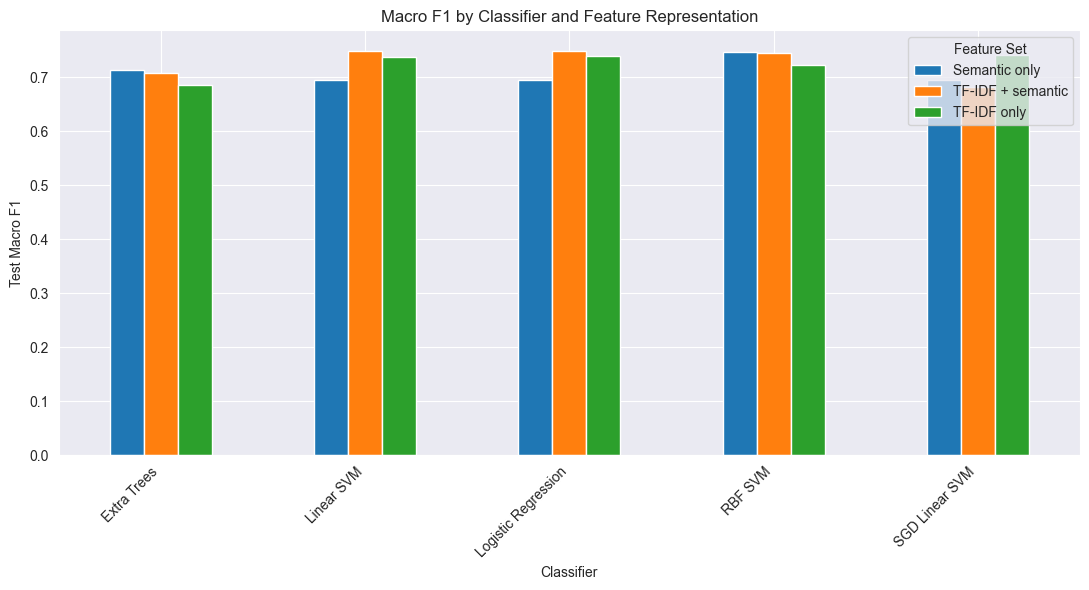

In [68]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = classifier_results_df.copy()

pivot_df = plot_df.pivot(
    index="Classifier",
    columns="Feature Set",
    values="Test Macro F1"
)

pivot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.ylabel("Test Macro F1")
plt.xlabel("Classifier")
plt.title("Macro F1 by Classifier and Feature Representation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

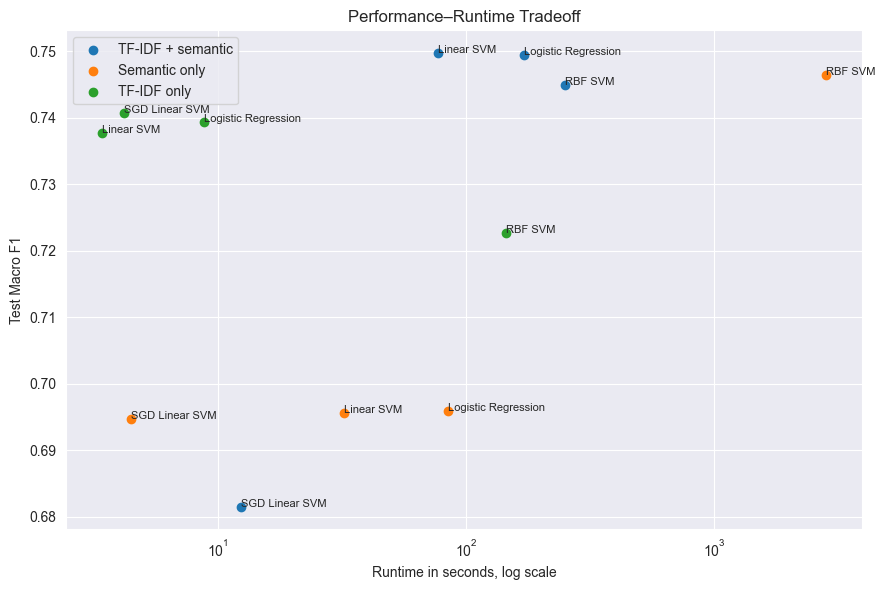

In [59]:
plt.figure(figsize=(9, 6))

for feature_set in classifier_results_df["Feature Set"].unique():
    subset = classifier_results_df[
        classifier_results_df["Feature Set"] == feature_set
    ]

    plt.scatter(
        subset["Runtime Seconds"],
        subset["Test Macro F1"],
        label=feature_set
    )

    for _, row in subset.iterrows():
        plt.annotate(
            row["Classifier"],
            (
                row["Runtime Seconds"],
                row["Test Macro F1"]
            ),
            fontsize=8
        )

plt.xscale("log")
plt.xlabel("Runtime in seconds, log scale")
plt.ylabel("Test Macro F1")
plt.title("Performance–Runtime Tradeoff")
plt.legend()
plt.tight_layout()
plt.show()

In [60]:
from sklearn.metrics import classification_report

for key, predictions in all_predictions.items():
    feature_set, classifier = key

    print("\n", feature_set, "-", classifier)
    print(
        classification_report(
            y_test,
            predictions
        )
    )


 TF-IDF only - Logistic Regression
              precision    recall  f1-score   support

Conservative       0.66      0.67      0.66       907
     Liberal       0.82      0.81      0.81      1664

    accuracy                           0.76      2571
   macro avg       0.74      0.74      0.74      2571
weighted avg       0.76      0.76      0.76      2571


 Semantic only - Logistic Regression
              precision    recall  f1-score   support

Conservative       0.57      0.71      0.63       907
     Liberal       0.82      0.71      0.76      1664

    accuracy                           0.71      2571
   macro avg       0.69      0.71      0.70      2571
weighted avg       0.73      0.71      0.71      2571


 TF-IDF + semantic - Logistic Regression
              precision    recall  f1-score   support

Conservative       0.67      0.69      0.68       907
     Liberal       0.83      0.81      0.82      1664

    accuracy                           0.77      2571
   macro avg

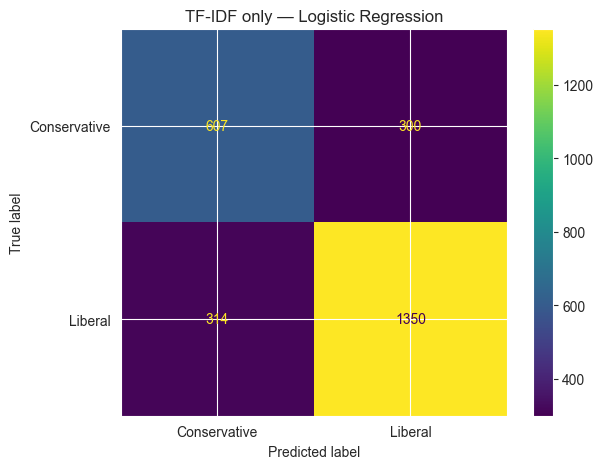

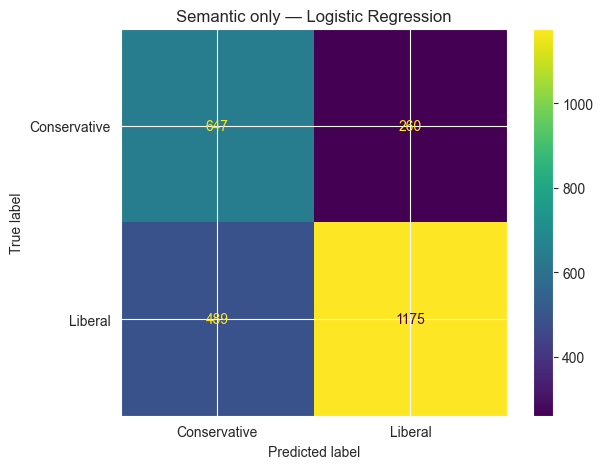

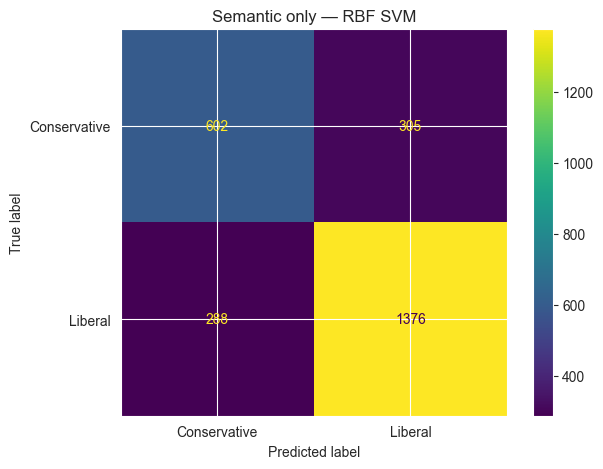

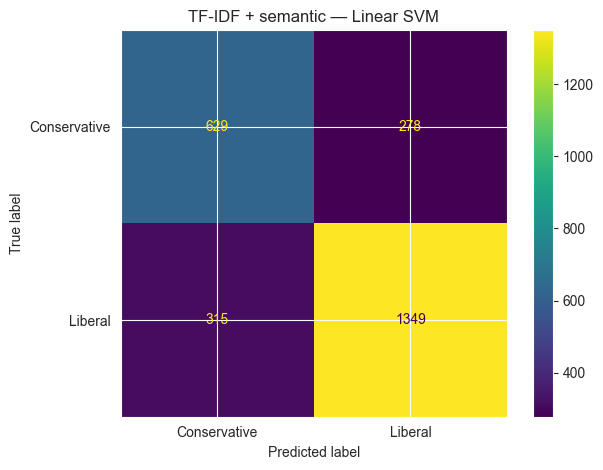

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

selected_models = [
    ("TF-IDF only", "Logistic Regression"),
    ("Semantic only", "Logistic Regression"),
    ("Semantic only", "RBF SVM"),
    ("TF-IDF + semantic", "Linear SVM")
]

for key in selected_models:
    predictions = all_predictions[key]

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions
    )

    plt.title(f"{key[0]} — {key[1]}")
    plt.tight_layout()
    plt.show()

In [62]:
moral_summary = (
    model_df
    .groupby("Political Lean")[
        moral_features + moral_contrast_features
    ]
    .mean()
    .T
)

moral_summary["Liberal_minus_Conservative"] = (
    moral_summary["Liberal"]
    - moral_summary["Conservative"]
)

moral_summary.sort_values(
    "Liberal_minus_Conservative",
    ascending=False
)

Political Lean,Conservative,Liberal,Liberal_minus_Conservative
fairness_minus_cheating,-0.039189,-0.018536,0.020652
moral_care,0.072050,0.091657,0.019606
moral_fairness,0.099440,0.116809,0.017370
moral_loyalty,0.092223,0.108867,0.016644
moral_liberty,0.121777,0.135156,0.013378
moral_purity,0.061767,0.074207,0.012440
moral_authority,0.071124,0.081911,0.010787
care_minus_harm,-0.028084,-0.017947,0.010137
moral_harm,0.100134,0.109603,0.009469
moral_betrayal,0.131872,0.140880,0.009008


In [63]:
semantic_subsets = {
    "Sentiment only": sentiment_features,
    "Moral only": moral_features + moral_contrast_features,
    "RoBERTa embeddings only": roberta_embedding_features,
    "RoBERTa + sentiment": (
        roberta_embedding_features + sentiment_features
    ),
    "RoBERTa + moral": (
        roberta_embedding_features
        + moral_features
        + moral_contrast_features
    ),
    "All semantic": semantic_features
}

In [64]:
error_df = X_test[["Text"]].copy()
error_df["true_label"] = y_test
error_df["tfidf_pred"] = all_predictions[
    ("TF-IDF only", "Logistic Regression")
]
error_df["semantic_pred"] = all_predictions[
    ("Semantic only", "RBF SVM")
]
error_df["combined_pred"] = all_predictions[
    ("TF-IDF + semantic", "Linear SVM")
]

In [65]:
semantic_wins = error_df[
    (error_df["semantic_pred"] == error_df["true_label"])
    & (error_df["tfidf_pred"] != error_df["true_label"])
]

semantic_wins[
    [
        "Text",
        "true_label",
        "tfidf_pred",
        "semantic_pred"
    ]
].head(20)

,Text,true_label,tfidf_pred,semantic_pred
2172,Capitalism and Australia’s Response to COVID-1...,Liberal,Conservative,Liberal
8881,EU to ban RT and Sputnik news (RT),Conservative,Liberal,Conservative
4319,So where do you guys stand? Do you prefer cent...,Liberal,Conservative,Liberal
11325,FBI Director Wray: Blown Away By the Level of ...,Conservative,Liberal,Conservative
6336,"Trump sues Facebook's Mark Zuckerberg, Twitter...",Liberal,Conservative,Liberal
371,"Bernie Sanders: ""We must stand with the Ukrain...",Liberal,Conservative,Liberal
6543,President Biden for the Nobel Peace Prize,Liberal,Conservative,Liberal
3477,Does Fox News not think of themselves as media...,Liberal,Conservative,Liberal
662,White House says Biden has agreed to meet with...,Liberal,Conservative,Liberal
5696,Two GOP operatives indicted for allegedly rout...,Liberal,Conservative,Liberal


In [69]:
semantic_rbf_search = all_searches[
    ("Semantic only", "RBF SVM")
]

semantic_rbf_model = semantic_rbf_search.best_estimator_

semantic_rbf_predictions = all_predictions[
    ("Semantic only", "RBF SVM")
]

              precision    recall  f1-score   support

Conservative       0.68      0.66      0.67       907
     Liberal       0.82      0.83      0.82      1664

    accuracy                           0.77      2571
   macro avg       0.75      0.75      0.75      2571
weighted avg       0.77      0.77      0.77      2571

[[ 602  305]
 [ 288 1376]]


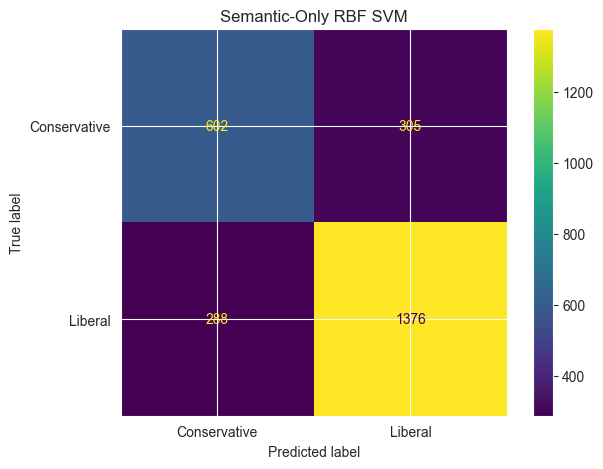

In [70]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print(
    classification_report(
        y_test,
        semantic_rbf_predictions
    )
)

print(
    confusion_matrix(
        y_test,
        semantic_rbf_predictions
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    semantic_rbf_predictions
)

plt.title("Semantic-Only RBF SVM")
plt.tight_layout()
plt.show()

In [71]:
semantic_subsets = {
    "Sentiment only": sentiment_features,

    "Moral only": (
        moral_features
        + moral_contrast_features
    ),

    "RoBERTa embeddings only":
        roberta_embedding_features,

    "RoBERTa + sentiment": (
        roberta_embedding_features
        + sentiment_features
    ),

    "RoBERTa + moral": (
        roberta_embedding_features
        + moral_features
        + moral_contrast_features
    ),

    "Sentiment + moral": (
        sentiment_features
        + moral_features
        + moral_contrast_features
    ),

    "All semantic features":
        semantic_features
}

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score
import time

semantic_ablation_results = []

for subset_name, subset_features in semantic_subsets.items():

    print("\nRunning:", subset_name)

    subset_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "classifier",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                cache_size=4000,
                random_state=42
            )
        )
    ])

    subset_search = GridSearchCV(
        estimator=subset_pipeline,
        param_grid={
            "classifier__C": [1, 3, 10],
            "classifier__gamma": [
                0.0001,
                0.001,
                0.01,
                "scale"
            ]
        },
        scoring="f1_macro",
        cv=3,
        n_jobs=-1,
        verbose=1
    )

    start_time = time.time()

    subset_search.fit(
        X_train[subset_features],
        y_train
    )

    subset_predictions = subset_search.predict(
        X_test[subset_features]
    )

    semantic_ablation_results.append({
        "Feature subset": subset_name,
        "Number of features": len(subset_features),
        "Accuracy": accuracy_score(
            y_test,
            subset_predictions
        ),
        "Test Macro F1": f1_score(
            y_test,
            subset_predictions,
            average="macro"
        ),
        "CV Macro F1": subset_search.best_score_,
        "Runtime Seconds": time.time() - start_time,
        "Best Parameters": subset_search.best_params_
    })


Running: Sentiment only
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: Moral only
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: RoBERTa embeddings only
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: RoBERTa + sentiment
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: RoBERTa + moral
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: Sentiment + moral
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Running: All semantic features
Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [73]:
semantic_ablation_df = (
    pd.DataFrame(semantic_ablation_results)
    .sort_values(
        "Test Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

semantic_ablation_df

,Feature subset,Number of features,Accuracy,Test Macro F1,CV Macro F1,Runtime Seconds,Best Parameters
0,RoBERTa + moral,786,0.771295,0.748307,0.740191,208.164708,"{'classifier__C': 3, 'classifier__gamma': 0.001}"
1,RoBERTa + sentiment,771,0.769350,0.747138,0.739362,205.317456,"{'classifier__C': 3, 'classifier__gamma': 0.001}"
2,All semantic features,789,0.769350,0.746363,0.740603,210.632826,"{'classifier__C': 3, 'classifier__gamma': 0.001}"
3,RoBERTa embeddings only,768,0.767795,0.745689,0.739762,213.830702,"{'classifier__C': 3, 'classifier__gamma': 0.001}"
4,Moral only,18,0.626993,0.613522,0.615917,9.686639,"{'classifier__C': 3, 'classifier__gamma': 'sca..."
5,Sentiment + moral,21,0.623882,0.610181,0.613372,9.836506,"{'classifier__C': 3, 'classifier__gamma': 'sca..."
6,Sentiment only,3,0.529366,0.507562,0.506094,12.290557,"{'classifier__C': 3, 'classifier__gamma': 'sca..."
